In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.spatial.distance import pdist
import seaborn as sns
from scipy.spatial.distance import cdist
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator
import glob

In [2]:

warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})



In [3]:
def plot_ibd_analysis(scenarios, sample_rate=1.0):
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    letters = ['a', 'b', 'c', 'd']

    for i, (label, config) in enumerate(scenarios.items()):
        if i >= len(axes): break
        ax = axes[i]
        folder = config['path']
        
        spatial_file = os.path.join(folder, 'All/data.dat')
        genome_file = os.path.join(folder, 'Genome/genome.dat')
        
        if not (os.path.exists(spatial_file) and os.path.exists(genome_file)):
            ax.text(0.5, 0.5, f"Missing Data:\n{label}", transform=ax.transAxes, ha='center', color='red', fontsize=20)
            continue

        print(f"Processing: {label}...")
        
        df = pd.read_csv(spatial_file, delim_whitespace=True, header=None,
                         names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
        
        with open(genome_file, 'r') as f:
            all_lines = [line.strip() for line in f if line.strip()]
        
        min_size = min(len(df), len(all_lines))
        df = df.iloc[:min_size]
        all_lines = all_lines[:min_size]

        sample_size = max(2, int(min_size * sample_rate))
        idx = np.random.choice(min_size, sample_size, replace=False)
        
        df_sub = df.iloc[idx].reset_index(drop=True)
        genomes = np.array([np.array(list(all_lines[j]), dtype=int) for j in idx])

        dist_geo = pdist(df_sub[['x', 'y']].values, metric='euclidean')
        dist_gen = pdist(genomes, metric='hamming')
        
        species_ids = df_sub['species'].values
      
        matrix_comparison = (species_ids[:, None] == species_ids)
        intra_mask = matrix_comparison[np.triu_indices(len(species_ids), k=1)]
        inter_mask = ~intra_mask 

        if np.any(inter_mask):
            ax.scatter(dist_geo[inter_mask], dist_gen[inter_mask], 
                       color='#999999', alpha=0.4, s=35, label='Interspecies', zorder=1, rasterized=True)

        if np.any(intra_mask):
            ax.scatter(dist_geo[intra_mask], dist_gen[intra_mask], 
                       color=config['color'], alpha=0.4, s=35, label='Intraspecies', zorder=2, rasterized=True)

        def fit_log_line(x_data, y_data, mask, ax, color, style, width, label_prefix, zorder):
            valid = (mask) & (x_data > 0) & (y_data > 0)
            if np.count_nonzero(valid) > 5:
                lx, ly = np.log10(x_data[valid]), np.log10(y_data[valid])
                m, b = np.polyfit(lx, ly, 1)
                x_fit = np.logspace(lx.min(), lx.max(), 100)
                y_fit = 10**(m * np.log10(x_fit) + b)
                ax.plot(x_fit, y_fit, color=color, lw=width, ls=style, 
                        label=f'{label_prefix}: {m:.2f}', zorder=zorder)

        fit_log_line(dist_geo, dist_gen, intra_mask, ax, 'black', '-', 5, 'Slope Intra', 5)
        fit_log_line(dist_geo, dist_gen, np.ones_like(intra_mask, dtype=bool), ax, 'black', '--', 3, 'Slope Total', 4)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1e0, 2e2)
        ax.set_ylim(1e-3, 1.5e0)
        
        ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=24, length=12, width=1.5)
        
        ax.set_xlabel('Geographic Distance', fontsize=28)
        ax.set_ylabel('Genetic Distance', fontsize=28)
        ax.set_title(label, fontsize=30, pad=15)
        ax.legend(fontsize=18, loc='lower right', frameon=False)
        ax.text(0.03, 0.93, letters[i], transform=ax.transAxes, fontsize=45, fontweight='bold')

    plt.tight_layout(pad=4.0)
    plt.savefig('IBD.pdf', dpi=300, bbox_inches='tight')
    plt.show()



Processing: $G = 0.05, \sigma_e = 0.05$...
Processing: $G = 0.05, \sigma_e = 0.40$...
Processing: $G = 0.30, \sigma_e = 0.05$...
Processing: $G = 0.30, \sigma_e = 0.40$...


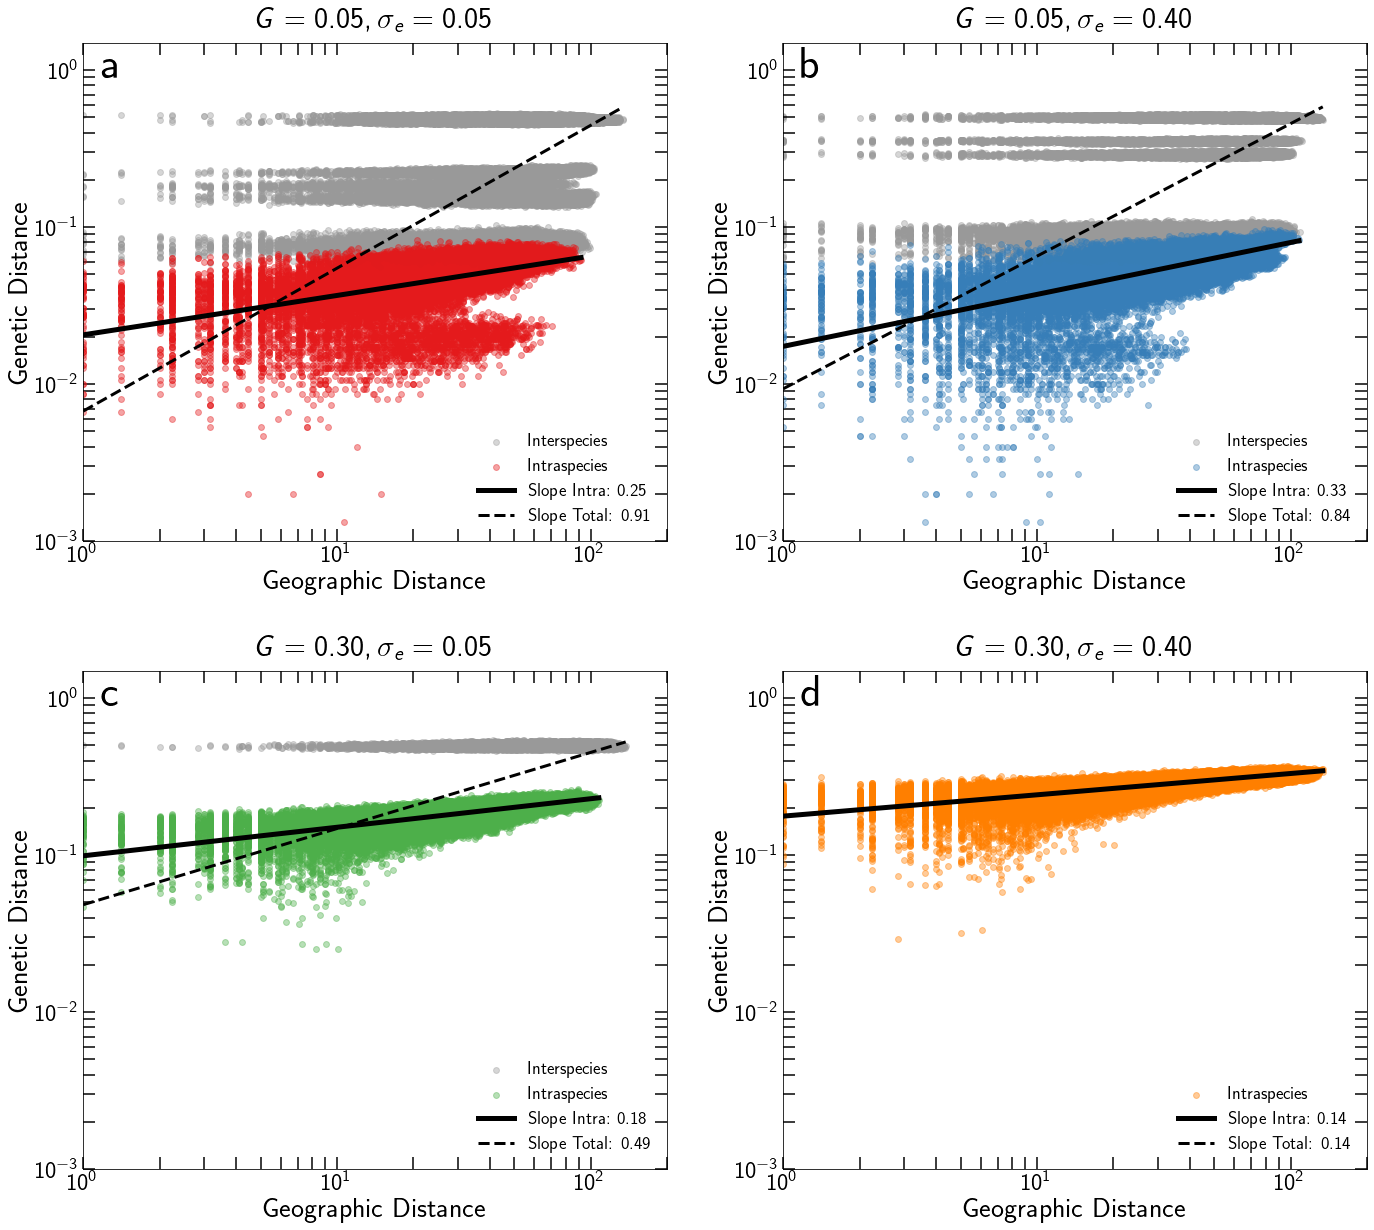

In [4]:

SCENARIOS = {
    r'$G = 0.05, \sigma_e = 0.05$': {'path': 'DATA/phenotype/G5sigma5/', 'color': '#e41a1c'},
    r'$G = 0.05, \sigma_e = 0.40$': {'path': 'DATA/phenotype/G5sigma40/', 'color': '#377eb8'},
    r'$G = 0.30, \sigma_e = 0.05$': {'path': 'DATA/phenotype/G30sigma5/', 'color': '#4daf4a'},
    r'$G = 0.30, \sigma_e = 0.40$': {'path': 'DATA/phenotype/G30sigma40/', 'color': '#ff7f00'}
}

plot_ibd_analysis(SCENARIOS, sample_rate=0.5)

# Phenotype distance and signature

In [5]:

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

def get_ordered_distance_matrix(base_path, scenario_path):
    spatial_file = os.path.join(base_path, scenario_path, 'All/data5000.dat')
    genome_file = os.path.join(base_path, scenario_path, 'phenotype/phegenome.dat')
    
    if not os.path.exists(spatial_file) or not os.path.exists(genome_file):
        return None

    df = pd.read_csv(spatial_file, sep=r'\s+', header=None,
                     names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
    
    with open(genome_file, 'r') as f:
        genomes = np.array([list(line.strip()) for line in f.readlines()], dtype=int)
    
    species_dist = df.groupby('species').apply(lambda g: pd.Series({
        'left': (g['x'] < 50).sum(), 'right': (g['x'] >= 50).sum()
    }), include_groups=False)
    
    spp_e1 = species_dist[species_dist['left'] >= species_dist['right']].index.tolist()
    spp_e2 = species_dist[species_dist['right'] > species_dist['left']].index.tolist()
    ordered_species = spp_e1 + spp_e2
    
    n_spp = len(ordered_species)
    n_loci = genomes.shape[1]
    
    if n_spp == 0: return None
    
    dist_matrix = np.zeros((n_spp, n_spp))
    for i, spp_a in enumerate(ordered_species):
        for j, spp_b in enumerate(ordered_species):
            if i <= j:
                gen_a = genomes[df['species'] == spp_a]
                gen_b = genomes[df['species'] == spp_b]
                dists = cdist(gen_a, gen_b, metric='cityblock') / n_loci
                avg_dist = np.mean(dists)
                dist_matrix[i, j] = dist_matrix[j, i] = avg_dist
    
    sequential_labels = [str(i+1) for i in range(n_spp)]
    return pd.DataFrame(dist_matrix, index=sequential_labels, columns=sequential_labels)



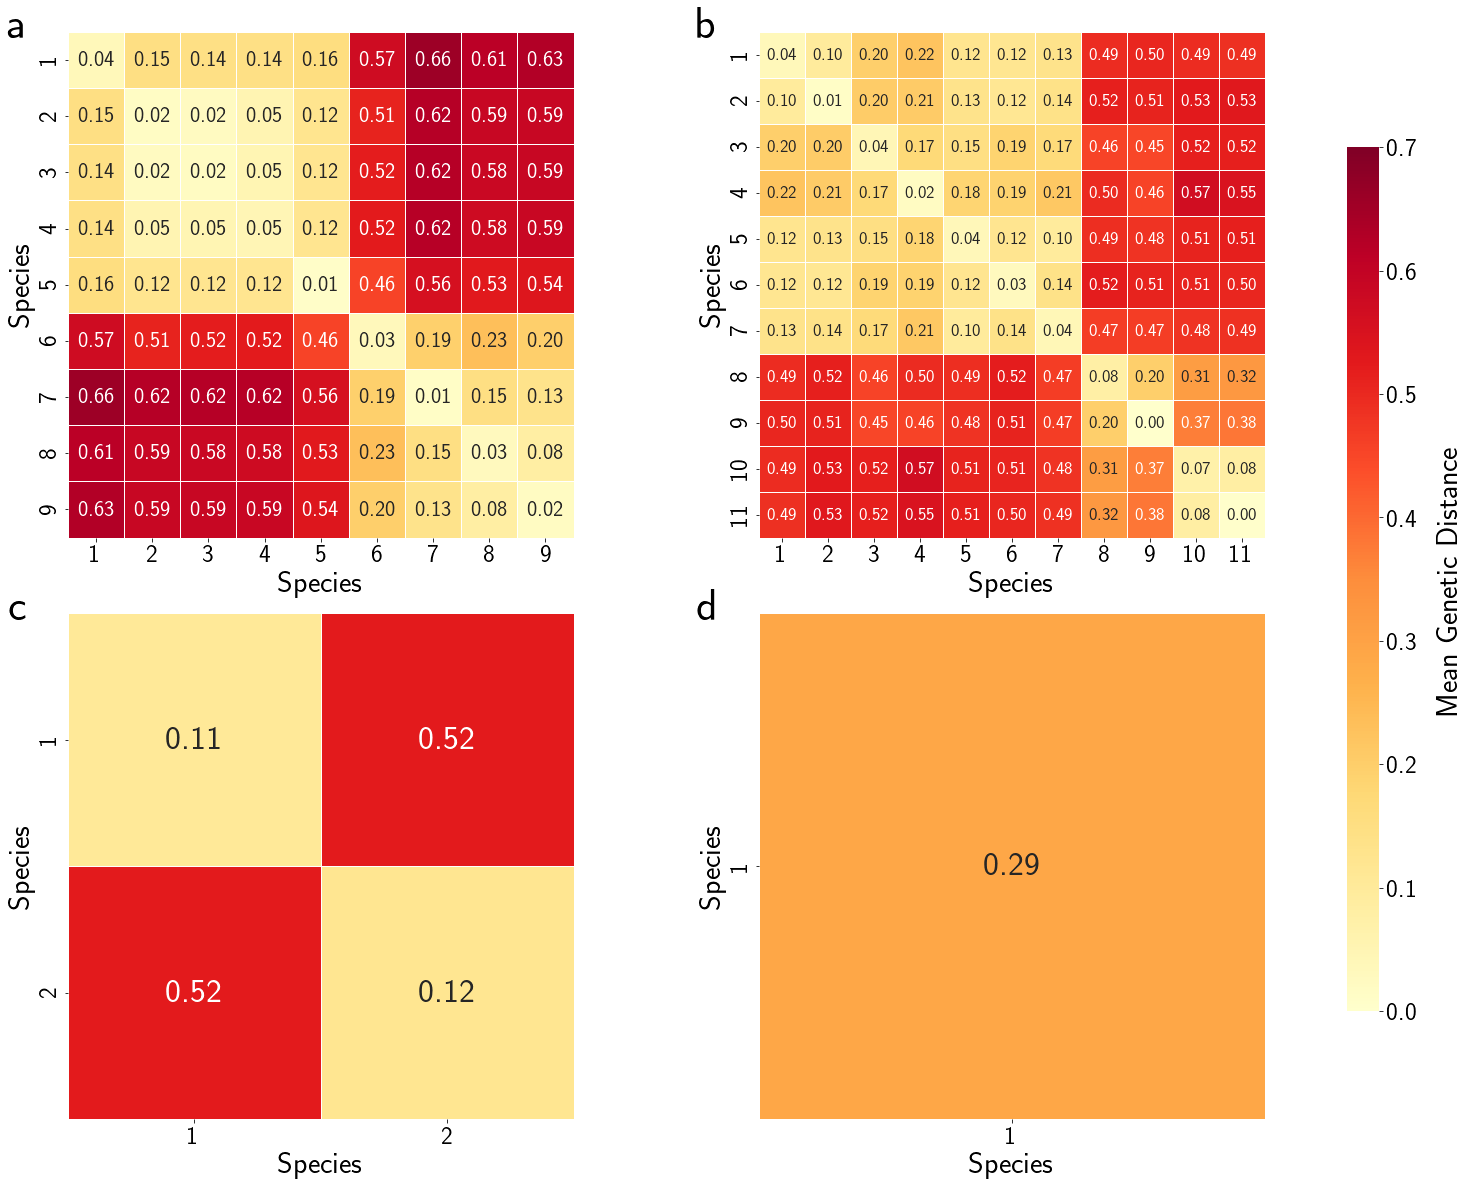

In [6]:
BASE = "code/DATA/heterogeneous/diffphen"
scenarios = [
    ("G5sigma5", "G5, $\sigma=5$"),
    ("G5sigma40", "G5, $\sigma=40$"),
    ("G30sigma5", "G30, $\sigma=5$"),
    ("G30sigma40", "G30, $\sigma=40$")
]

VMIN, VMAX = 0.0, 0.7
TAM_TITULO = 35
TAM_LABEL = 30
TAM_TICKS = 25
TAM_ANNOT_BASE = 22 
LETRAS = ['a', 'b', 'c', 'd']

fig, axes = plt.subplots(2, 2, figsize=(22, 20))
axes = axes.flatten()

cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6]) 

for i, (path, label) in enumerate(scenarios):
    ax = axes[i]
    df_dist = get_ordered_distance_matrix(BASE, path)
    
    ax.text(-0.08, 1.05, LETRAS[i], transform=ax.transAxes, 
            fontsize=TAM_TITULO + 10, fontweight='bold', va='top', ha='right')

    if df_dist is not None:
        n_spp = len(df_dist)
        
        if n_spp > 10:
            current_annot_size = TAM_ANNOT_BASE - 4 
        elif n_spp <= 3:
            current_annot_size = TAM_ANNOT_BASE + 12
        else:
            current_annot_size = TAM_ANNOT_BASE

        sns.heatmap(df_dist, 
                    ax=ax, 
                    annot=True, 
                    fmt=".2f", 
                    cmap="YlOrRd", 
                    vmin=VMIN, vmax=VMAX,
                    cbar=(i == 0), 
                    cbar_ax=cbar_ax, 
                    square=True, 
                    annot_kws={'size': current_annot_size, 'weight': 'bold'},
                    linewidths=0.5 if n_spp < 15 else 0.1)

        ax.set_xlabel(r'$\mathsf{Species}$', fontsize=TAM_LABEL)
        ax.set_ylabel(r'$\mathsf{Species}$', fontsize=TAM_LABEL)
        ax.tick_params(labelsize=TAM_TICKS)
    else:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=TAM_TICKS)
        ax.set_axis_off()

cbar_ax.tick_params(labelsize=TAM_TICKS)
cbar_ax.set_ylabel(r'$\mathsf{Mean\ Genetic\ Distance}$', fontsize=TAM_LABEL, labelpad=20)

plt.subplots_adjust(right=0.9, left=0.1, hspace=0.15, wspace=0.2)

plt.savefig('matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

def get_signatures(base_path, scenario_path):
    spatial_file = os.path.join(base_path, scenario_path, 'All/data5000.dat')
    genome_file = os.path.join(base_path, scenario_path, 'phenotype/phegenome.dat')
    
    if not os.path.exists(spatial_file) or not os.path.exists(genome_file):
        return None, None

    df = pd.read_csv(spatial_file, sep=r'\s+', header=None,
                     names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
    
    with open(genome_file, 'r') as f:
        genomes = np.array([list(line.strip()) for line in f.readlines()], dtype=int)
    
    df_gen = pd.DataFrame(genomes)
    df_gen['species'] = df['species'].values
    df_gen['x'] = df['x'].values
    
    if df['species'].nunique() > 1:
        signatures = df_gen.drop(columns='x').groupby('species').mean()
        species_dist = df.groupby('species').apply(lambda g: pd.Series({
            'left': (g['x'] < 50).sum(), 'right': (g['x'] >= 50).sum()
        }), include_groups=False)
        
        sig_e1 = signatures.loc[species_dist[species_dist['left'] >= species_dist['right']].index]
        idx_e2 = species_dist[species_dist['right'] > species_dist['left']].index
        sig_e2 = signatures.loc[idx_e2]
        is_single_species = False
    else:
        sig_e1 = df_gen[df_gen['x'] < 50].drop(columns=['species', 'x']).mean().to_frame().T
        sig_e2 = df_gen[df_gen['x'] >= 50].drop(columns=['species', 'x']).mean().to_frame().T
        sig_e1.index, sig_e2.index = ['Pop. E1'], ['Pop. E2']
        is_single_species = True

    return sig_e1, sig_e2, is_single_species


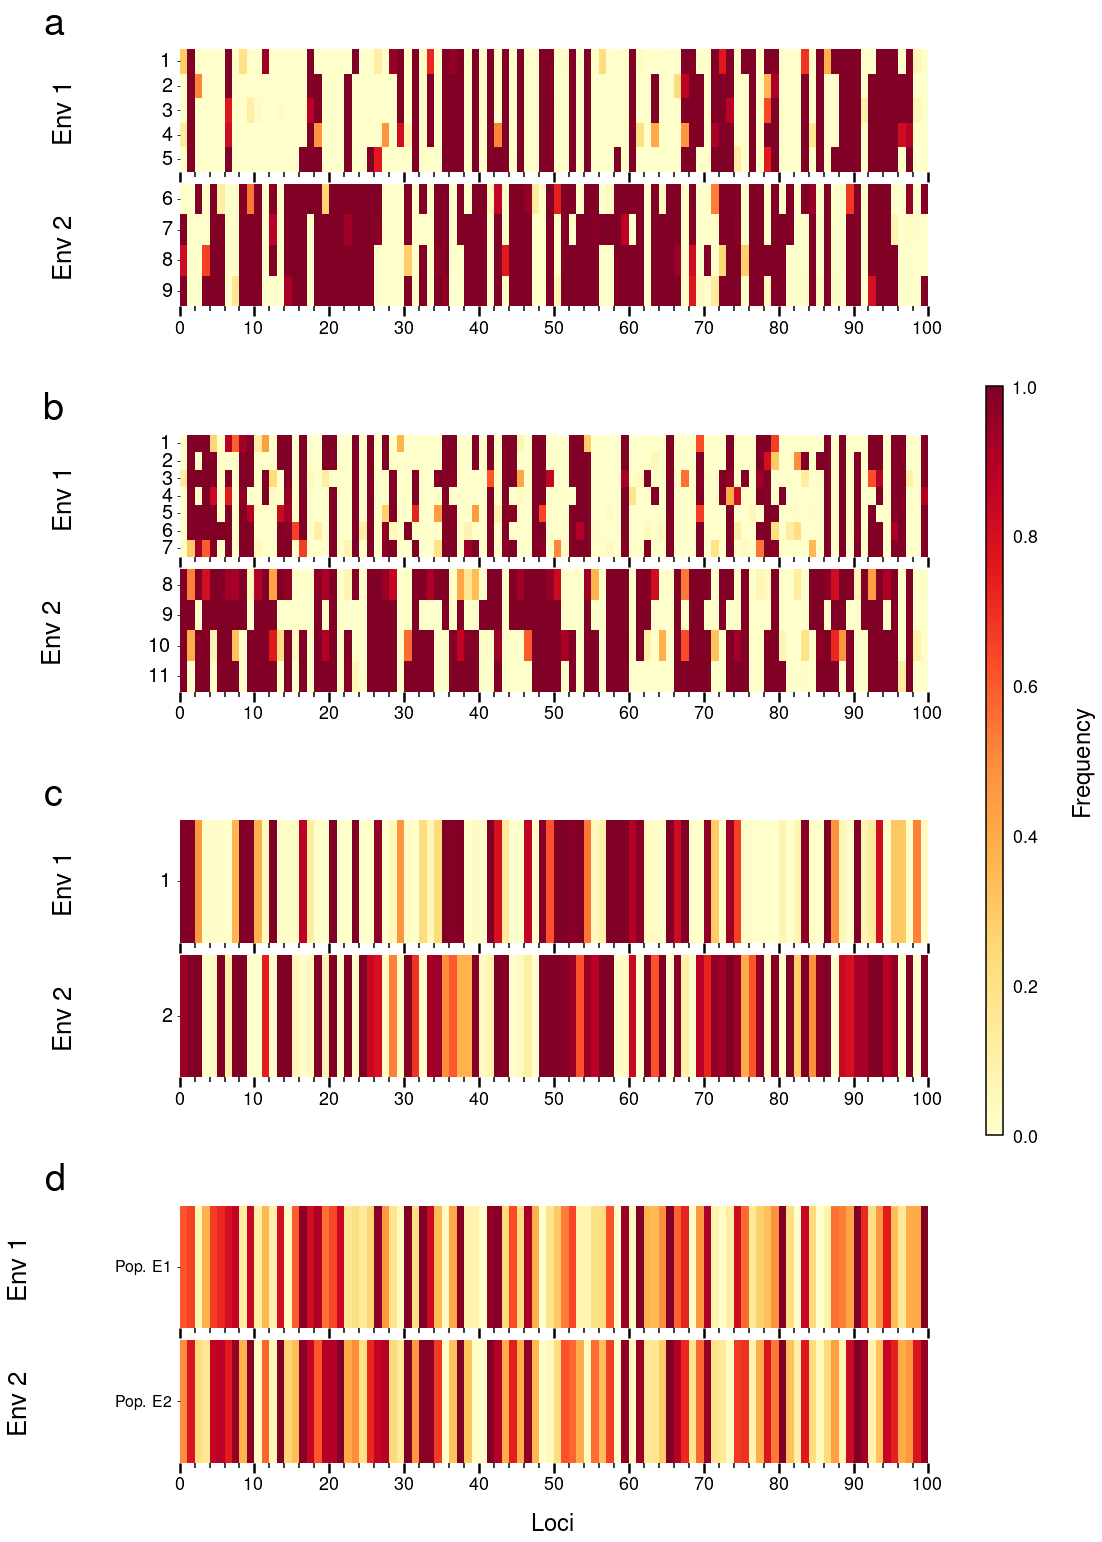

In [8]:
BASE = "code/DATA/heterogeneous/diffphen" 
CENARIOS = [
    ("G5sigma5", "G5, sigma=5"), 
    ("G5sigma40", "G5, sigma=40"), 
    ("G30sigma5", "G30, sigma=5"), 
    ("G30sigma40", "G30, sigma=40")
]
LETRAS = ['a', 'b', 'c', 'd']

TAM_LETRA_PAINEL = 38  
TAM_LABEL_AMBIENTE = 26 
TAM_LABEL_ESPECIES = 20 
TAM_TICKS = 18         
TAM_LABEL_LOCI = 24

fig = plt.figure(figsize=(16, 26))
outer_grid = gridspec.GridSpec(4, 1, hspace=0.5, left=0.2, right=0.85)

for i, (folder, title_label) in enumerate(CENARIOS):
    sig_e1, sig_e2, is_single = get_signatures(BASE, folder)
    if sig_e1 is None: continue
    
    if is_single:
        labels_e1 = ["Pop. E1"]
        labels_e2 = ["Pop. E2"]
    else:
        n_e1 = len(sig_e1)
        n_e2 = len(sig_e2)
        labels_e1 = [str(j + 1) for j in range(n_e1)]
        labels_e2 = [str(j + 1 + n_e1) for j in range(n_e2)]
    
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], hspace=0.1)
    
    ax1 = fig.add_subplot(inner_grid[0, 0])
    ax2 = fig.add_subplot(inner_grid[1, 0])

    heatmap_kws = {'cmap': "YlOrRd", 'cbar': False, 'vmin': 0, 'vmax': 1, 'linewidths': 0}
    sns.heatmap(sig_e1, ax=ax1, **heatmap_kws)
    sns.heatmap(sig_e2, ax=ax2, **heatmap_kws)

    ax1.text(-0.18, 1.35, LETRAS[i], transform=ax1.transAxes, 
             fontsize=TAM_LETRA_PAINEL, fontweight='bold', va='top')

    for ax, sig_data, env_name, y_labels in zip([ax1, ax2], [sig_e1, sig_e2], ['Env 1', 'Env 2'], [labels_e1, labels_e2]):
        ax.set_ylabel(env_name, fontsize=TAM_LABEL_AMBIENTE, fontweight='bold', labelpad=85)
        ax.set_yticks(np.arange(len(sig_data)) + 0.5)
        
        f_size = TAM_LABEL_ESPECIES - 4 if is_single else TAM_LABEL_ESPECIES
        ax.set_yticklabels(y_labels, rotation=0, fontsize=f_size)
        
        n_loci = sig_data.shape[1]
        tick_pos = np.arange(0, n_loci + 1, 10)
        ax.set_xticks(tick_pos)
        ax.xaxis.set_minor_locator(MultipleLocator(2))
        ax.tick_params(axis='x', which='major', labelsize=TAM_TICKS, length=10, width=2.5, direction='out', bottom=True)
        ax.tick_params(axis='x', which='minor', length=5, width=1.5, direction='out', bottom=True)
        
        if ax == ax1:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels([str(int(x)) for x in tick_pos])
            if i == 3: 
                ax.set_xlabel('Loci', fontsize=TAM_LABEL_LOCI, labelpad=20)

cbar_ax = fig.add_axes([0.90, 0.30, 0.015, 0.4]) 
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=TAM_TICKS, direction='in', length=0, pad=10)
cbar.set_label('Frequency', size=TAM_LABEL_LOCI, labelpad=35, fontweight='bold')
cbar.outline.set_linewidth(1.5)

plt.savefig('Signatures.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Boundary

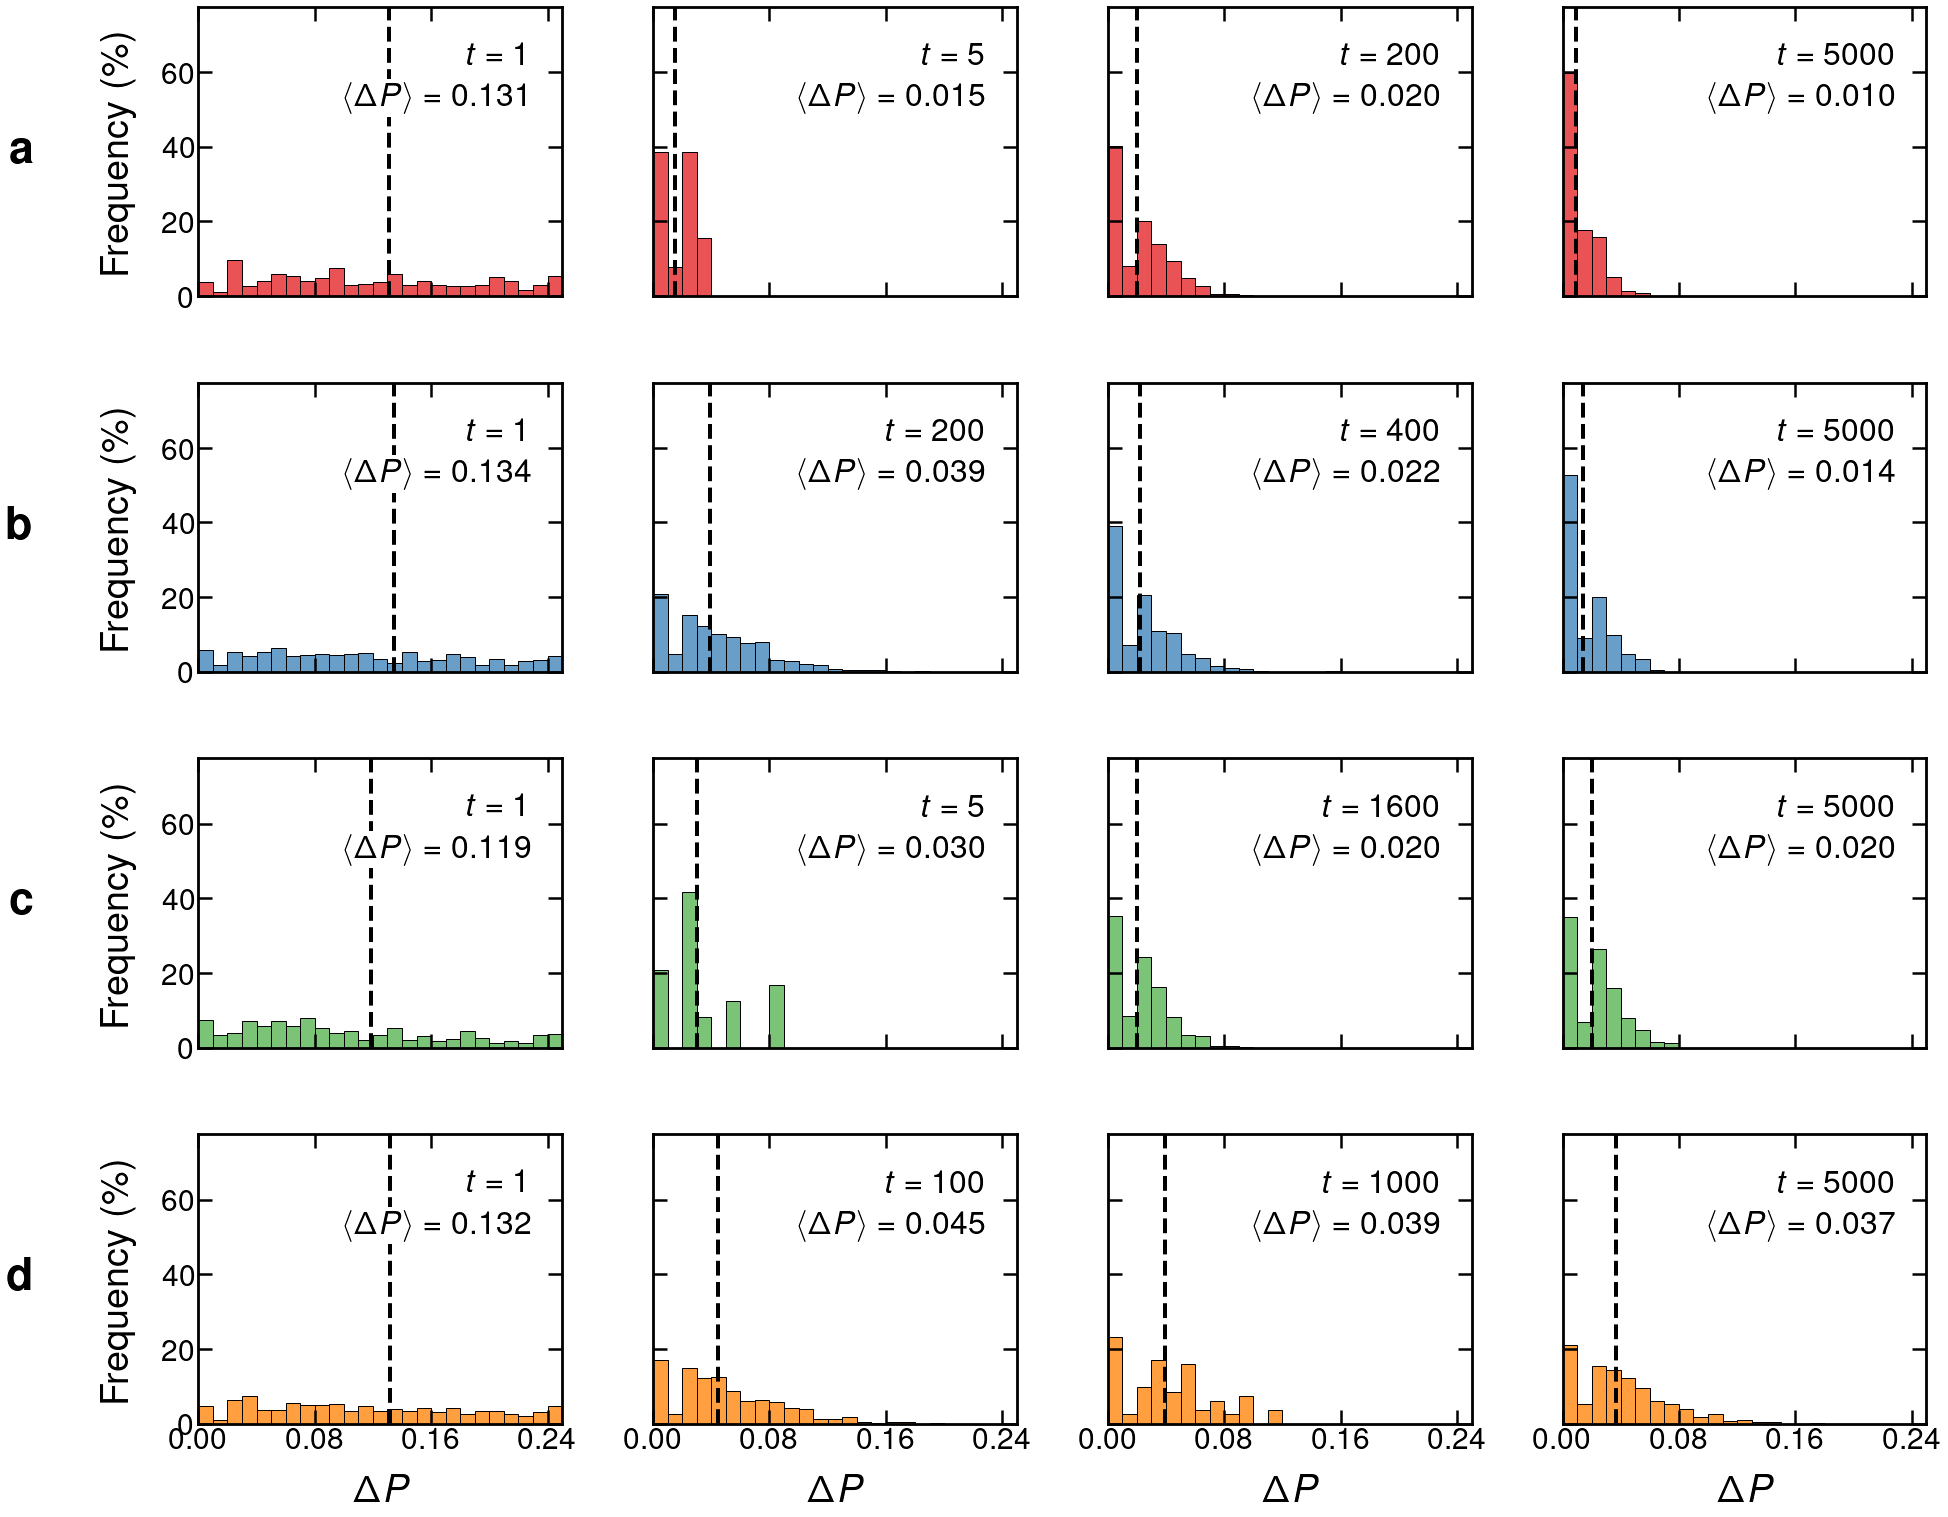

In [9]:

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'axes.labelsize': 38,      
    'xtick.labelsize': 30,     
    'ytick.labelsize': 30,     
    'axes.linewidth': 2.8,     
    'xtick.major.size': 14,    
    'xtick.major.width': 2.5,  
    'ytick.major.size': 14,    
    'ytick.major.width': 2.5,  
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True
})


Htimes = {
    r'$G = 0.05, \sigma_e = 0.05$': [1, 5, 200, 5000],
    r'$G = 0.05, \sigma_e = 0.40$': [1, 200, 400, 5000],
    r'$G = 0.30, \sigma_e = 0.05$': [1, 5, 1600, 5000],
    r'$G = 0.30, \sigma_e = 0.40$': [1, 100, 1000, 5000],
}

directories = {
    r'$G = 0.05, \sigma_e = 0.05$': 'DATA/phenotype/G5sigma5/diff/',
    r'$G = 0.05, \sigma_e = 0.40$': 'DATA/phenotype/G5sigma40/diff/',
    r'$G = 0.30, \sigma_e = 0.05$': 'DATA/phenotype/G30sigma5/diff/',
    r'$G = 0.30, \sigma_e = 0.40$': 'DATA/phenotype/G30sigma40/diff/',
}

colors = {
    r'$G = 0.05, \sigma_e = 0.05$': '#e41a1c', 
    r'$G = 0.05, \sigma_e = 0.40$': '#377eb8', 
    r'$G = 0.30, \sigma_e = 0.05$': '#4daf4a', 
    r'$G = 0.30, \sigma_e = 0.40$': '#ff7f00', 
}


plot_data = {}
max_percent = 0

for label, folder in directories.items():
    if not os.path.exists(folder): continue
    files = sorted(glob.glob(os.path.join(folder, "diff_*.txt")), 
                   key=lambda x: int(x.split('_')[-1].split('.')[0]))
    scenario_raw = {}
    for f in files:
        it = int(f.split('_')[-1].split('.')[0])
        try:
            data = np.abs(np.loadtxt(f))
            if data.size < 2: continue
            scenario_raw[it] = data
        except: continue
    
    plot_data[label] = {}
    for target_t in Htimes[label]:
        if not scenario_raw: continue
        actual_t = min(scenario_raw.keys(), key=lambda x: abs(x - target_t))
        val_data = scenario_raw[actual_t]
        plot_data[label][actual_t] = val_data
        
        counts, _ = np.histogram(val_data, bins=25, range=(0, 0.25))
        current_max = (counts.max() / counts.sum()) * 100
        if current_max > max_percent: max_percent = current_max

fixed_ylim = max_percent * 1.3 


fig, axes = plt.subplots(4, 4, figsize=(30, 24), sharex=True, sharey=True)
plt.subplots_adjust(left=0.15, top=0.92, bottom=0.1, right=0.95, wspace=0.25, hspace=0.3)

row_letters = ['a', 'b', 'c', 'd']
scenario_list = list(Htimes.keys())

for i, label in enumerate(scenario_list):
    if label not in plot_data: continue
    times_sorted = sorted(plot_data[label].keys())
    
    for j, actual_t in enumerate(times_sorted):
        ax = axes[i, j]
        val_data = plot_data[label][actual_t]
        

        sns.histplot(val_data, bins=25, binrange=(0, 0.25), kde=False, ax=ax, 
                     color=colors[label], stat='percent', alpha=0.75, edgecolor='black')
        

        mu = np.mean(val_data)
        ax.axvline(mu, color='black', linestyle='--', lw=4, zorder=5)
        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        
        common_bbox = dict(facecolor='white', alpha=1.0, edgecolor='none', pad=3)
        

        ax.text(0.92, 0.88, f'$t = {actual_t}$', transform=ax.transAxes, 
                fontsize=32, fontweight='bold', va='top', ha='right',
                bbox=common_bbox, zorder=10)
        

        ax.text(0.92, 0.74, f'$\\langle \\Delta P \\rangle = {mu:.3f}$', 
                transform=ax.transAxes, fontsize=32, va='top', ha='right',
                bbox=common_bbox, zorder=10)


        if j == 0:
            ax.text(-0.45, 0.5, f'\\textbf{{{row_letters[i]}}}', transform=ax.transAxes, 
                    fontsize=45, fontweight='bold', va='center', ha='right')
            ax.set_ylabel('Frequency (\%)', labelpad=25)
        
        ax.set_ylim(0, fixed_ylim)
        ax.set_xlim(0, 0.25)
        if i == 3: ax.set_xlabel(r'$\Delta P$', labelpad=20)

plt.savefig('dist.pdf', dpi=300, bbox_inches='tight')
plt.show()